### Build Basic Langraph(GraphAPI) Chatbot

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


graph_builder=StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="openai/gpt-oss-20b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FCEDC01E10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FCEDD5D510>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph=graph_builder.compile()

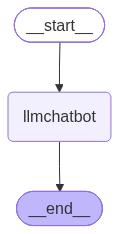

In [9]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response=graph.invoke({"messages":"Tell About AI"})
response["messages"][-1].content

'### Artificial Intelligence (AI) – A Quick Guide\n\n| Topic | What it means |\n|-------|---------------|\n| **Definition** | AI is the field of computer science that builds systems capable of performing tasks that normally require human intelligence. These tasks include reasoning, learning, perception, language understanding, and decision‑making. |\n| **Core Pillars** | 1. **Machine Learning (ML)** – Algorithms that learn patterns from data.<br>2. **Neural Networks & Deep Learning** – Layered models that mimic brain‑like computation.<br>3. **Natural Language Processing (NLP)** – Understanding and generating human language.<br>4. **Computer Vision** – Interpreting visual data (images, video).<br>5. **Robotics & Autonomous Systems** – Embedding AI in physical agents. |\n| **Historical Milestones** | - **1950s** – Turing’s “Imitation Game” and early symbolic AI.<br>- **1960s‑70s** – Expert systems (MYCIN, XCON).<br>- **1980s** – Machine learning re‑emerges with decision trees, Bayesian n

In [11]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hi there! I'm doing great—thanks for asking. How about you? 😊


### CHATBOT WITH TOOLS

In [12]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("what is langraph")

{'query': 'what is langraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/@jagadeesan.ganesh/a-comprehensive-guide-to-langraph-step-by-step-with-examples-56ab31a987ee',
   'title': 'A Comprehensive Guide to Langraph: Step-by- ...',
   'content': '## Conclusion\n\nLangraph is an advanced, scalable solution for building AI systems that require both information retrieval and language generation. By integrating RAG techniques, Langraph improves the quality of responses while scaling for large datasets. Whether you’re building a chatbot, a virtual assistant, or a large-scale search engine, Langraph can help you achieve high-performance results. [...] Langraph is an emerging technology in the world of natural language processing (NLP), focusing on simplifying complex interactions between humans and AI agents. This guide will take you through the process of understanding Langraph and applying it to real-world use cases. We will cover 

In [13]:
## CUSTOM FUNCTION

def multiply(a:int, b:int) -> int:
    """multiply a and b
    Args:
        a(int): first int
        b(int): second int
        
    Returns:
        int: output int
    """
    return a*b

In [14]:
tools=[tool,multiply]

In [15]:
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FCEDC01E10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FCEDD5D510>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

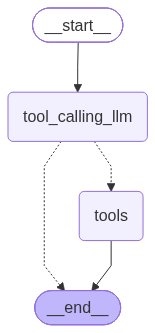

In [16]:
## STATGRAPH
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##  NODE DEFINATION
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## GRAPH
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## EDGES
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## decide if need to call tool or directly go to end
    tools_condition
)
builder.add_edge("tools",END)


## COMPILE GRAPH
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



In [17]:
response=graph.invoke({"messages":"what is 2 multiplied by 3"})
response["messages"][-1].content

'2 multiplied by 3 equals **6**.'

In [18]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3
================================== Ai Message ==================================

2 multiplied by 3 equals **6**.


In [19]:
graph.invoke({"messages":"what is 2 multiply by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3
================================== Ai Message ==================================

2 multiplied by 3 equals **6**.


In [20]:
response=graph.invoke({"messages":"give me the recent ai news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ba3aaa8f-813c-4f09-bd07-8b5d36e26d64)
 Call ID: fc_ba3aaa8f-813c-4f09-bd07-8b5d36e26d64
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026 - Google Blog", "content": "Summaries were generated by Google AI. Generative AI is experimental. \n\nGoogle released a bunch of new AI updates in July to make your devices smarter and more helpful. They launched faster Gemini models, better t

### RE ACT AGENT ARCHITECTURE

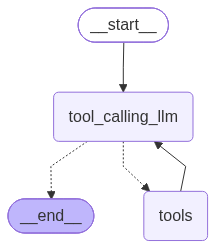

In [21]:
## STATGRAPH
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##  NODE DEFINATION
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## GRAPH
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## EDGES
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## decide if need to call tool or directly go to end
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


## COMPILE GRAPH
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



In [22]:
response=graph.invoke({"messages":"give me the recent ai news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0de609cc-d2cd-4902-bf1f-548de763a1a8)
 Call ID: fc_0de609cc-d2cd-4902-bf1f-548de763a1a8
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026 - Google Blog", "content": "Summaries were generated by Google AI. Generative AI is experimental. \n\nGoogle released a bunch of new AI updates in July to make your devices smarter and more helpful. They launched faster Gemini models, better t

### ADDING MEMORY IN AGENTIC LANGGRAPH

In [23]:
response=graph.invoke({"messages":"Hello my name is Ifham Ahmed Ansari"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ifham Ahmed Ansari
================================== Ai Message ==================================

Hello Ifham Ahmed Ansari! Nice to meet you. How can I help you today?


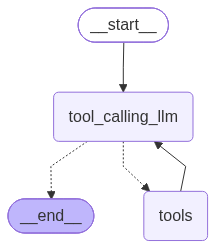

In [24]:
## STATGRAPH
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

##  NODE DEFINATION
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## GRAPH
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## EDGES
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## decide if need to call tool or directly go to end
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


## COMPILE GRAPH
graph=builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))



In [25]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hello my name is Ifham Ahmed Ansari"},config=config)
response

{'messages': [HumanMessage(content='Hello my name is Ifham Ahmed Ansari', additional_kwargs={}, response_metadata={}, id='378d3f42-bdb3-4130-8807-f442ff169de7'),
  AIMessage(content='Hello Ifham! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'User introduced themselves. Need to respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 363, 'total_tokens': 398, 'completion_time': 0.042442282, 'completion_tokens_details': {'reasoning_tokens': 10}, 'prompt_time': 0.017684333, 'prompt_tokens_details': None, 'queue_time': 0.194255322, 'total_time': 0.060126615}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1c0f5282a2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a024aa-d88f-71b0-8738-500d3eec5f0a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 363, 'output_tokens': 35, 'total_tokens': 398, 'output_toke

In [26]:
response=graph.invoke({"messages":"Hello my name is Ifham Ahmed Ansari"},config=config)
response["messages"][-1].content

'Hello Ifham! It’s great to hear from you. How can I assist you today?'

### STREAMING

In [27]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [28]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

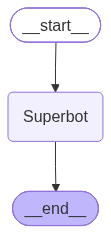

In [29]:
graph=StateGraph(State)

graph.add_node("Superbot",superbot)

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
## Invocation

config = {"configurable":  {"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi my name is ifham and i like ufc"}, config)

{'messages': [HumanMessage(content='Hi my name is ifham and i like ufc', additional_kwargs={}, response_metadata={}, id='8795d895-094d-4337-9ff0-27ea820aef7e'),
  AIMessage(content='Hey Ifham! 👋🏼 Great to meet a UFC fan—what’s your favorite fighter or recent match you’ve been excited about? If you have any questions about UFC history, stats, or just want to chat about upcoming fights, I’m all ears!', additional_kwargs={'reasoning_content': 'User says: "Hi my name is ifham and i like ufc". It\'s a casual greeting. They want to chat? The user says "Hi my name is ifham and i like ufc". So respond politely, maybe ask about UFC. The user hasn\'t asked a question. The user is greeting. So respond in friendly manner. Also mention that I\'m ChatGPT. The user is a fan of UFC. Ask them about their favorite fighters.'}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 82, 'total_tokens': 236, 'completion_time': 0.15774373, 'completion_tokens_details': {'reasoning_toke

### Streaming

Methods: stream() and astream()
- These are sync and async method for streaming back results

Additional parameters in streaming mode for graph state is:
- Values: Stream full state of graph when node is called. Give all desired states/messages
- Updates: Stream updated to state of graph when node is called. Give latest state/message/specific output

In [31]:
config = {"configurable":  {"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"Hi my name is ifham and i like ufc"}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hey Ifham! 👋 Great to meet a UFC fan. Who’s your all‑time favorite fighter, or which weight class do you find the most exciting? Also, any recent bouts or upcoming events you’re looking forward to? Let's dive into some octagon action!", additional_kwargs={'reasoning_content': 'We need to respond in a friendly way. The user says "Hi my name is ifham and i like ufc". We can respond. The user wants maybe a conversation about UFC. We can ask about their favorite fighters, weight classes, or events. We\'ll keep it friendly, ask them questions.'}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 82, 'total_tokens': 208, 'completion_time': 0.1511985, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.004027572, 'prompt_tokens_details': None, 'queue_time': 0.375999395, 'total_time': 0.155226072}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 

In [32]:
for chunk in graph_builder.stream({"messages":"Hi my name is ifham and i like ufc"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is ifham and i like ufc', additional_kwargs={}, response_metadata={}, id='5c433bdf-e778-43a7-87bd-668eb79bd08d'), AIMessage(content="Hey Ifham! 👋 Great to meet a UFC fan. Who’s your all‑time favorite fighter, or which weight class do you find the most exciting? Also, any recent bouts or upcoming events you’re looking forward to? Let's dive into some octagon action!", additional_kwargs={'reasoning_content': 'We need to respond in a friendly way. The user says "Hi my name is ifham and i like ufc". We can respond. The user wants maybe a conversation about UFC. We can ask about their favorite fighters, weight classes, or events. We\'ll keep it friendly, ask them questions.'}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 82, 'total_tokens': 208, 'completion_time': 0.1511985, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.004027572, 'prompt_tokens_details': None, 'queue_time': 0.375999395

In [33]:
config = {"configurable":  {"thread_id":"4"}}
for chunk in graph_builder.stream({"messages":"Hi my name is ifham and i like ufc"}, config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Hey Ifham! 👋🏼 It’s great to meet a UFC fan. Which fighters or events do you enjoy the most? I can help you keep up with the latest news, stats, or even find some classic matches to watch. Just let me know what you’re into!', additional_kwargs={'reasoning_content': 'User says: "Hi my name is ifham and i like ufc". They are greeting. We respond friendly. It\'s a simple greeting. We can ask about UFC preferences. Also mention we can help with UFC.'}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 82, 'total_tokens': 193, 'completion_time': 0.132027411, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.00397925, 'prompt_tokens_details': None, 'queue_time': 0.239826169, 'total_time': 0.136006661}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4f7e7dc26e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a024aa-e2d4

In [34]:
for chunk in graph_builder.stream({"messages":"I also like football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is ifham and i like ufc', additional_kwargs={}, response_metadata={}, id='11140ce2-e87e-474a-bb9f-ea4c4f9b2a1c'), AIMessage(content='Hey Ifham! 👋🏼 It’s great to meet a UFC fan. Which fighters or events do you enjoy the most? I can help you keep up with the latest news, stats, or even find some classic matches to watch. Just let me know what you’re into!', additional_kwargs={'reasoning_content': 'User says: "Hi my name is ifham and i like ufc". They are greeting. We respond friendly. It\'s a simple greeting. We can ask about UFC preferences. Also mention we can help with UFC.'}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 82, 'total_tokens': 193, 'completion_time': 0.132027411, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.00397925, 'prompt_tokens_details': None, 'queue_time': 0.239826169, 'total_time': 0.136006661}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4f7

In [35]:
# ASTREAM: More detail information

config = {"configurable":  {"thread_id":"5"}}
async for event in graph_builder.astream_events({"messages":"Hi my name is ifham and i like ufc"}, config):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is ifham and i like ufc'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a024aa-e7a8-7dd1-acf4-b03d5842a859', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is ifham and i like ufc', additional_kwargs={}, response_metadata={}, id='be5e9ba3-4445-40ce-b9ae-289cd40e668f')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '01a024aa-e7b4-7782-b185-f9c5f3f4b245', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:9c15c4f5-0a13-70f0-d09f-6c0c84cf7fc3'}, 'parent_ids': ['01a024aa-e7a8-7dd1-acf4-b03d5842a859']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='H

### HUMAN IN THE LOOP

In [36]:
import os
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FCEF3BBDD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FCEF3585D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [53]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages:Annotated[list, add_messages]

graph_builder=StateGraph(State)


## human assistance tool
@tool
def human_assistance(query: str) -> str:
    """request for assistance and guidance from human"""   # llm check if human message is related to this is will call this tool base on the text given in this line
    human_response = interrupt({"query": query})
    return human_response

tool = TavilySearch(max_results=2)
tools=[tool, human_assistance]
llm_with_tools=llm.bind_tools(tools)

def chatbot(state:State):
    message= llm_with_tools.invoke(state["messages"])
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

## interrupt will happen in tools node because human assistance is the tool
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")



In [54]:
memory = MemorySaver()
graph=graph_builder.compile(checkpointer=memory)

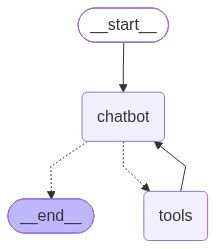

In [55]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [56]:
user_input="I need some expert guidance and assistance for building an AI Agent. Could you request assistance for me?"
config = {"configurable":  {"thread_id":"4"}}

events=  graph.stream(
    {"messages":user_input},
     config,
     stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


## it stop after tool call of human assistance because it expecting human to provide some event/input so it can continue

================================ Human Message =================================

I need some expert guidance and assistance for building an AI Agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_93d29e17-29e7-4025-a3de-ed6bb07f0b20)
 Call ID: fc_93d29e17-29e7-4025-a3de-ed6bb07f0b20
  Args:
    query: I need some expert guidance and assistance for building an AI Agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_93d29e17-29e7-4025-a3de-ed6bb07f0b20)
 Call ID: fc_93d29e17-29e7-4025-a3de-ed6bb07f0b20
  Args:
    query: I need some expert guidance and assistance for building an AI Agent.


In [57]:
## now we provide human response so llm can asnwer user query
human_response=("We, the experts are here to help! We'd recommend you to check out langgraph to build your AI Agent.",
                "it is much reliable and extensible than simple autonomous agents")          

human_command=Command(resume=human_response)

events=  graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_93d29e17-29e7-4025-a3de-ed6bb07f0b20)
 Call ID: fc_93d29e17-29e7-4025-a3de-ed6bb07f0b20
  Args:
    query: I need some expert guidance and assistance for building an AI Agent.
================================= Tool Message =================================
Name: human_assistance

["We, the experts are here to help! We'd recommend you to check out langgraph to build your AI Agent.", "it is much reliable and extensible than simple autonomous agents"]
================================== Ai Message ==================================

Absolutely! Here’s what the experts had to say:

1. **Leverage a Proven Framework**  
   * **LangGraph** is highly recommended for building AI agents. It’s designed for reliability and extensibility, making it a solid foundation for both simple and complex autonomous agents.

2. **Why LangGraph?**  
   * **Modular Architecture** – Easily swap out 

### BUILDING MCP SERVER & INTEGRATION OF MCP 